In [4]:
!pip install PyGithub pandas matplotlib seaborn -q
print("All libraries installed")

All libraries installed


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import os
import time
import subprocess
from github import Github, GithubException
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

# Disable automatic retry to avoid long backoffs
g = Github(GITHUB_TOKEN, retry=None)

os.chdir('/content')
if not os.path.exists('/content/ml-technical-debt-analysis'):
    repo_url = 'https://vidhumol:' + GITHUB_TOKEN + '@github.com/vidhumol/ml-technical-debt-analysis.git'
    subprocess.run(['git', 'clone', repo_url])

df_satd  = pd.read_csv('ml-technical-debt-analysis/data/raw/satd_results.csv')
df_repos = pd.read_csv('ml-technical-debt-analysis/data/raw/repo_metadata.csv')

print("SATD records loaded  : " + str(len(df_satd)))
print("Repos loaded         : " + str(len(df_repos)))
print("Categories           : " + str(df_repos['category'].unique().tolist()))

SATD records loaded  : 3089
Repos loaded         : 100
Categories           : ['Deep Learning', 'NLP', 'Computer Vision', 'MLOps', 'AutoML/RL']


/tmp/ipykernel_16457/2552078976.py:16: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g = Github(GITHUB_TOKEN, retry=None)


In [10]:
MULTI_FILE_PATTERNS = {
    'notebook': {
        'extensions': ['.ipynb'],
        'patterns'  : [r'\bTODO\b', r'\bFIXME\b', r'\bHACK\b', r'#\s*deprecated']
    },
    'cicd': {
        'extensions': ['.yml', '.yaml', 'Dockerfile', '.sh'],
        'patterns'  : [r'\bTODO\b', r'\bFIXME\b', r'HARDCODED', r'#\s*temporary']
    },
    'dependency': {
        'extensions': ['requirements.txt', 'setup.py', 'pyproject.toml'],
        'patterns'  : [r'#\s*TODO.*upgrade', r'#\s*deprecated',
                       r'#\s*pin', r'#\s*FIXME']
    },
    'documentation': {
        'extensions': ['.md', '.rst'],
        'patterns'  : [r'\bTODO\b', r'\bFIXME\b', r'Coming soon',
                       r'Work in progress', r'\bWIP\b', r'Not yet implemented']
    }
}

print("File type patterns defined")
print("Scanning types : " + str(list(MULTI_FILE_PATTERNS.keys())))

File type patterns defined
Scanning types : ['notebook', 'cicd', 'dependency', 'documentation']


In [11]:
def scan_repo_nonpython(repo_full_name, category):
    results = []
    try:
        repo     = g.get_repo(repo_full_name)
        contents = repo.get_contents("")

        for item in contents:
            if item.type == "dir":
                continue

            for file_type, config in MULTI_FILE_PATTERNS.items():
                matched = any(
                    item.name.endswith(ext) or item.name == ext
                    for ext in config['extensions']
                )
                if matched:
                    try:
                        raw_content = item.decoded_content.decode('utf-8', errors='ignore')

                        if item.name.endswith('.ipynb'):
                            try:
                                nb        = json.loads(raw_content)
                                lines_all = []
                                for cell in nb.get('cells', []):
                                    lines_all.extend(cell.get('source', []))
                                raw_content = '\n'.join(lines_all)
                            except:
                                pass

                        lines = raw_content.split('\n')
                        for line_num, line in enumerate(lines, 1):
                            for pattern in config['patterns']:
                                if re.search(pattern, line, re.IGNORECASE):
                                    results.append({
                                        'repo_name'  : repo_full_name,
                                        'category'   : category,
                                        'file_type'  : file_type,
                                        'file_name'  : item.name,
                                        'line_number': line_num,
                                        'line_content': line.strip()[:200]
                                    })
                                    break
                    except:
                        pass

    except GithubException as e:
        # Skip forbidden or not found repos immediately - no backoff
        print("Skipping " + repo_full_name + " : " + str(e.status) + " " + str(e.data.get('message', '')))
    except Exception as e:
        print("Skipping " + repo_full_name + " : " + str(e)[:50])

    return results

print("Scan function updated - skips forbidden repos immediately")

Scan function updated - skips forbidden repos immediately


In [12]:
OUTPUT_NB08 = 'ml-technical-debt-analysis/data/processed/nonpython_satd.csv'

# Resume from checkpoint if exists
if os.path.exists(OUTPUT_NB08):
    df_existing   = pd.read_csv(OUTPUT_NB08)
    done_repos    = set(df_existing['repo_name'].unique().tolist())
    all_results   = df_existing.to_dict('records')
    print("Resuming - already scanned : " + str(len(done_repos)) + " repos")
else:
    done_repos  = set()
    all_results = []
    print("Starting fresh scan")

repos_list = df_repos[['repo_name', 'category']].drop_duplicates()
pending    = repos_list[~repos_list['repo_name'].isin(done_repos)]

print("Total repos    : " + str(len(repos_list)))
print("Pending repos  : " + str(len(pending)))
print("Estimated time : " + str(round(len(pending) * 3 / 60, 1)) + " minutes")
print("\nStarting scan...")

for i, (idx, row) in enumerate(pending.iterrows()):
    repo_name = row['repo_name']
    category  = row['category']

    print("[" + str(i+1) + "/" + str(len(pending)) + "] Scanning : " + repo_name)
    results = scan_repo_nonpython(repo_name, category)
    all_results.extend(results)
    print("  Found : " + str(len(results)) + " non-Python SATD items")

    # Save checkpoint every 10 repos
    if (i + 1) % 10 == 0:
        pd.DataFrame(all_results).to_csv(OUTPUT_NB08, index=False)
        print("Checkpoint saved - " + str(i+1) + " repos done")

    time.sleep(2)

df_nonpy = pd.DataFrame(all_results)
df_nonpy.to_csv(OUTPUT_NB08, index=False)

print("\n" + "=" * 60)
print("SCAN COMPLETE")
print("=" * 60)
print("Total non-Python SATD found : " + str(len(df_nonpy)))
print("Repos scanned               : " + str(df_nonpy['repo_name'].nunique()))

Resuming - already scanned : 10 repos
Total repos    : 99
Pending repos  : 89
Estimated time : 4.5 minutes

Starting scan...
[1/89] Scanning : open-mmlab/mmdetection
Skipping open-mmlab/mmdetection : 403 API rate limit exceeded for user ID 36961958. If you reach out to GitHub Support for help, please include the request ID ABFC:1E47E3:26662D:92B436:69FF5FEB and timestamp 2026-05-09 16:25:15 UTC. For more on scraping GitHub and how it may affect your rights, please review our Terms of Service (https://docs.github.com/en/site-policy/github-terms/github-terms-of-service)
  Found : 0 non-Python SATD items
[2/89] Scanning : huggingface/pytorch-image-models
Skipping huggingface/pytorch-image-models : 403 API rate limit exceeded for user ID 36961958. If you reach out to GitHub Support for help, please include the request ID ABFC:1E47E3:267349:92E618:69FF5FEB and timestamp 2026-05-09 16:25:17 UTC. For more on scraping GitHub and how it may affect your rights, please review our Terms of Service

In [13]:
df_nonpy = pd.read_csv('ml-technical-debt-analysis/data/processed/nonpython_satd.csv')

print("=" * 60)
print("NON-PYTHON SATD BY FILE TYPE AND ML CATEGORY")
print("=" * 60)

cross = pd.crosstab(df_nonpy['category'], df_nonpy['file_type'])
print(cross.to_string())

print("\n" + "=" * 60)
print("TOTAL NON-PYTHON SATD BY CATEGORY")
print("=" * 60)
print(df_nonpy.groupby('category')['repo_name'].count().sort_values(ascending=False).to_string())

print("\n" + "=" * 60)
print("PYTHON vs NON-PYTHON SATD COMPARISON")
print("=" * 60)

python_counts   = df_satd.groupby('category')['line_content'].count()
nonpython_counts = df_nonpy.groupby('category')['line_content'].count()

comparison = pd.DataFrame({
    'python_satd'    : python_counts,
    'nonpython_satd' : nonpython_counts
}).fillna(0)

comparison['total']             = comparison['python_satd'] + comparison['nonpython_satd']
comparison['nonpython_percent'] = round(comparison['nonpython_satd'] / comparison['total'] * 100, 1)
comparison['underestimate_pct'] = round(comparison['nonpython_satd'] / comparison['python_satd'] * 100, 1)

print(comparison.to_string())

print("\nKey Finding:")
print("Python-only analysis misses " + str(round(comparison['nonpython_percent'].mean(), 1)) +
      "% of total SATD on average")

NON-PYTHON SATD BY FILE TYPE AND ML CATEGORY
file_type        cicd  dependency  documentation  notebook
category                                                  
Computer Vision     3           1              0         0
Deep Learning      14           2             15        15
NLP                10           3             13         0

TOTAL NON-PYTHON SATD BY CATEGORY
category
Deep Learning      46
NLP                26
Computer Vision     4

PYTHON vs NON-PYTHON SATD COMPARISON
                 python_satd  nonpython_satd  total  nonpython_percent  underestimate_pct
category                                                                                 
AutoML/RL                263             0.0  263.0                0.0                0.0
Computer Vision          401             4.0  405.0                1.0                1.0
Deep Learning            673            46.0  719.0                6.4                6.8
MLOps                    994             0.0  994.0           

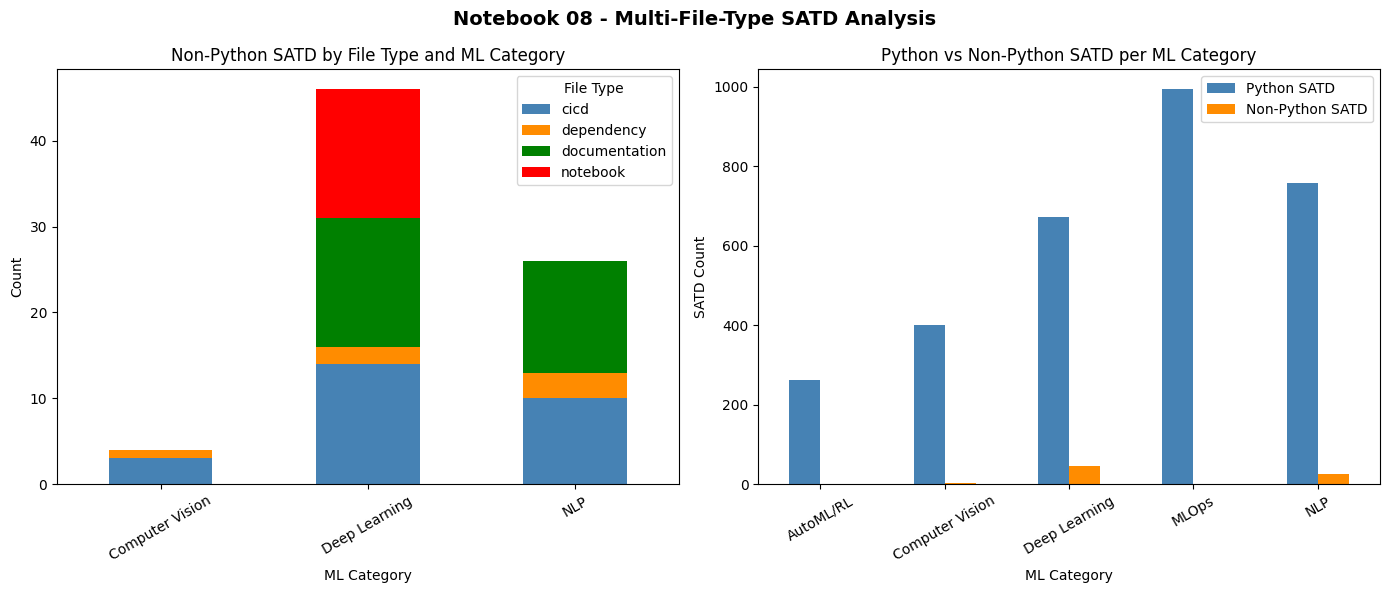

Visualizations saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Notebook 08 - Multi-File-Type SATD Analysis', fontsize=14, fontweight='bold')

# Plot 1 - Stacked bar by file type and category
cross_plot = pd.crosstab(df_nonpy['category'], df_nonpy['file_type'])
cross_plot.plot(kind='bar', stacked=True, ax=axes[0],
                color=['steelblue', 'darkorange', 'green', 'red'])
axes[0].set_title('Non-Python SATD by File Type and ML Category')
axes[0].set_xlabel('ML Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='File Type', loc='upper right')

# Plot 2 - Python vs Non-Python comparison
comparison_plot = comparison[['python_satd', 'nonpython_satd']]
comparison_plot.plot(kind='bar', ax=axes[1],
                     color=['steelblue', 'darkorange'])
axes[1].set_title('Python vs Non-Python SATD per ML Category')
axes[1].set_xlabel('ML Category')
axes[1].set_ylabel('SATD Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['Python SATD', 'Non-Python SATD'])

plt.tight_layout()
plt.savefig('ml-technical-debt-analysis/data/processed/nb08_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved")

In [15]:
print("=" * 60)
print("NOTEBOOK 08 - FINAL SUMMARY")
print("=" * 60)

total_python    = len(df_satd)
total_nonpython = len(df_nonpy)
total_all       = total_python + total_nonpython
underestimate   = round(total_nonpython / total_all * 100, 1)

print("Python SATD found          : " + str(total_python))
print("Non-Python SATD found      : " + str(total_nonpython))
print("Total SATD                 : " + str(total_all))
print("Non-Python percentage      : " + str(underestimate) + "%")
print("\nKey Finding:")
print("Python-only analysis underestimates total SATD by " +
      str(underestimate) + "% across all ML repositories")
print("\nFile type breakdown:")
print(df_nonpy['file_type'].value_counts().to_string())

os.chdir('/content/ml-technical-debt-analysis')
subprocess.run(['git', 'config', 'user.email', 'your-email@gmail.com'])
subprocess.run(['git', 'config', 'user.name', 'vidhumol'])
subprocess.run(['git', 'pull', 'origin', 'main'])
subprocess.run(['git', 'add', 'data/processed/nonpython_satd.csv'])
subprocess.run(['git', 'add', 'data/processed/nb08_analysis.png'])
subprocess.run(['git', 'commit', '-m',
                'Add Notebook 08 outputs - multi-file-type SATD analysis'])
push = subprocess.run(['git', 'push', 'origin', 'main'],
                       capture_output=True, text=True)
print(push.stdout)
print("Notebook 08 complete and pushed to GitHub")

NOTEBOOK 08 - FINAL SUMMARY
Python SATD found          : 3089
Non-Python SATD found      : 76
Total SATD                 : 3165
Non-Python percentage      : 2.4%

Key Finding:
Python-only analysis underestimates total SATD by 2.4% across all ML repositories

File type breakdown:
file_type
documentation    28
cicd             27
notebook         15
dependency        6

Notebook 08 complete and pushed to GitHub
